# 1. Problem Statement

* The objective of this project is to analyze bike rental data and predict the daily bike rental count (cnt) based on environmental and seasonal factors.
* The project also aims to compare different machine learning models and select the best-performing model for prediction.

# 2. Import Libraries

* The required Python libraries are imported for data analysis, visualization, and machine learning.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Load Dataset

* The bike rental dataset is loaded using Pandas for further analysis.


In [2]:
df = pd.read_csv("day.csv")

df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


# 4. Data Understanding

* The dataset is examined to understand its structure, data types, statistical summary, missing values, and duplicate records.


In [3]:
# Dataset shape
df.shape

(731, 16)

In [4]:
# Column names
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [5]:
# Data types and information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [6]:
# Statistical summary
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [7]:
# Missing values
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [8]:
# Duplicate records
df.duplicated().sum()

np.int64(0)

In [9]:
# Check the first records
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [10]:
# Check the last records
df.tail()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796
730,731,2012-12-31,1,1,12,0,1,1,2,0.215833,0.223487,0.577500,0.154846,439,2290,2729


# 5. Data Cleaning

* The dataset is cleaned by converting the date column, checking for duplicate records, validating the target variable, and removing the unnecessary record index.


In [11]:
# Convert date
df["dteday"] = pd.to_datetime(df["dteday"])

df["dteday"].dtype

dtype('<M8[ns]')

In [12]:
# Check duplicates
df.duplicated().sum()

np.int64(0)

In [13]:
# Validate total rentals
(df["casual"] + df["registered"] == df["cnt"]).all()

np.True_

In [14]:
# Remove instant
df.drop("instant", axis=1, inplace=True)

In [15]:
# Final check
df.head()

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [16]:
df.shape

(731, 15)

# 6. Exploratory Data Analysis

* Exploratory Data Analysis is performed to understand the distribution of bike rentals and the relationship between rental demand and different seasonal, weather, and environmental factors.


### 1. Distribution of Bike Rentals

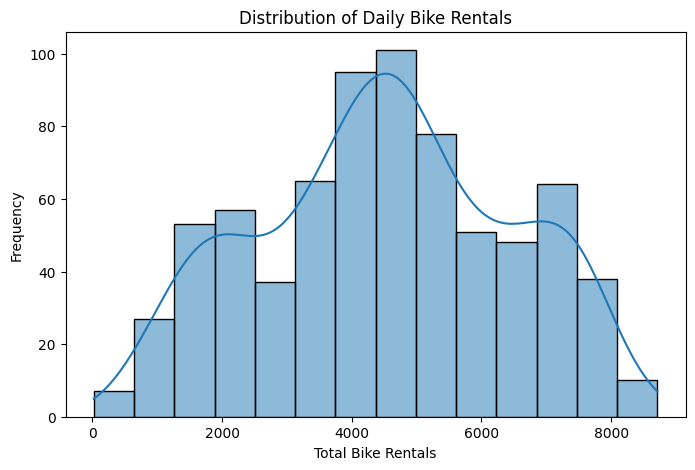

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(df["cnt"], kde=True)
plt.title("Distribution of Daily Bike Rentals")
plt.xlabel("Total Bike Rentals")
plt.ylabel("Frequency")
plt.show()

### 2. Bike Rentals by Season

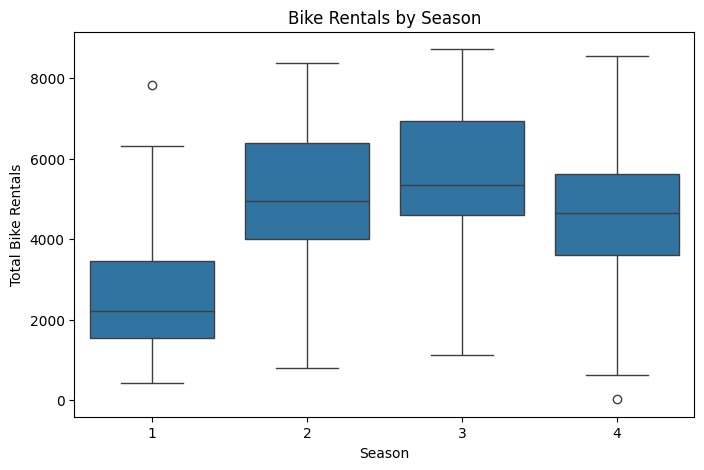

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="season", y="cnt", data=df)
plt.title("Bike Rentals by Season")
plt.xlabel("Season")
plt.ylabel("Total Bike Rentals")
plt.show()

### 3. Bike Rentals by Year

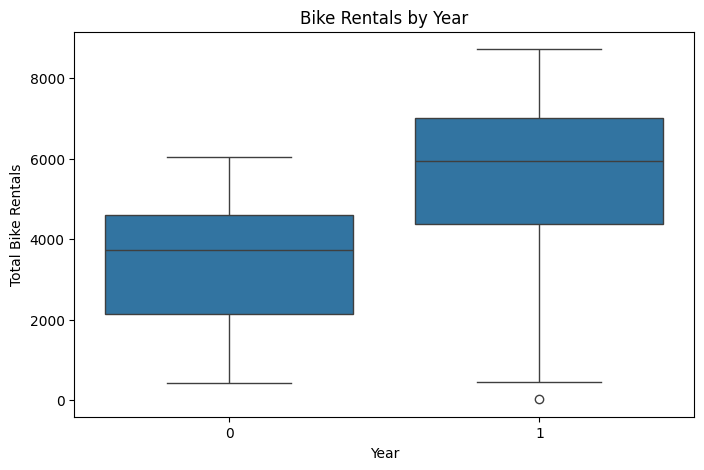

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="yr", y="cnt", data=df)
plt.title("Bike Rentals by Year")
plt.xlabel("Year")
plt.ylabel("Total Bike Rentals")
plt.show()

### 4. Bike Rentals by Weather

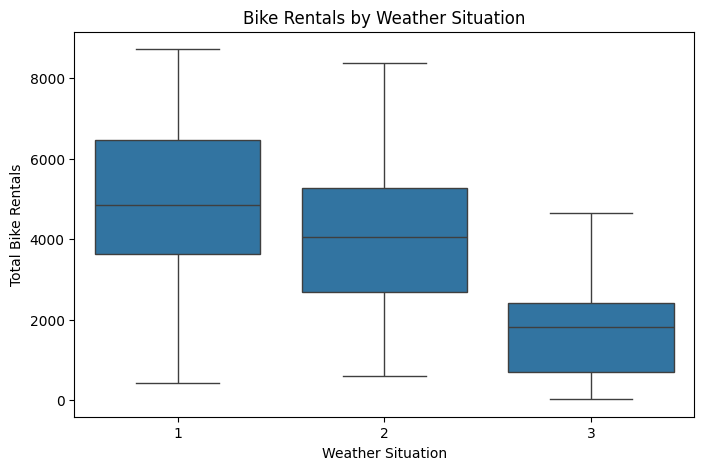

In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="weathersit", y="cnt", data=df)
plt.title("Bike Rentals by Weather Situation")
plt.xlabel("Weather Situation")
plt.ylabel("Total Bike Rentals")
plt.show()

### 5. Temperature vs Bike Rentals

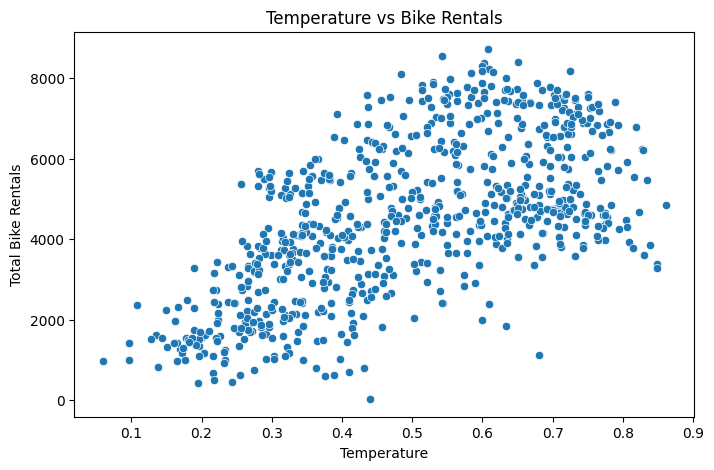

In [21]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="temp", y="cnt", data=df)
plt.title("Temperature vs Bike Rentals")
plt.xlabel("Temperature")
plt.ylabel("Total Bike Rentals")
plt.show()

### 6. Humidity vs Bike Rentals

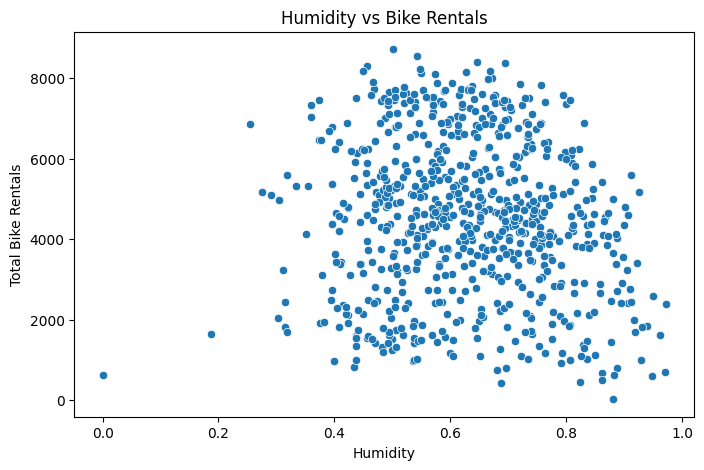

In [22]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="hum", y="cnt", data=df)
plt.title("Humidity vs Bike Rentals")
plt.xlabel("Humidity")
plt.ylabel("Total Bike Rentals")
plt.show()


### EDA Findings

* Bike rental demand varies significantly across seasons and years.
* Summer shows higher rental demand compared with winter.
* Rental demand increased in 2012 compared with 2011.
* Clear weather conditions are associated with higher bike rentals.
* Temperature has a positive relationship with rental demand, while higher humidity generally reduces demand.


### 7. Correlation Heatmap

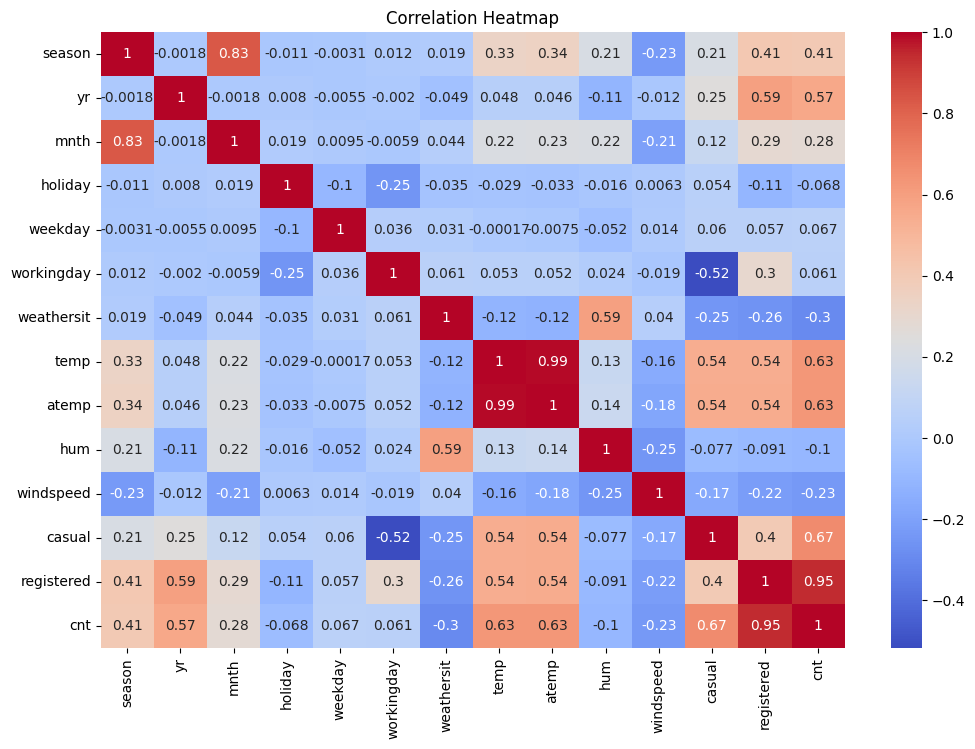

In [23]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Correlation Findings

* Temperature (`temp`) has a strong positive relationship with bike rental demand.
* Feeling temperature (`atemp`) also has a strong positive relationship with rental demand.
* Year (`yr`) has a moderate positive relationship with bike rentals.
* Humidity (`hum`) and windspeed show negative relationships with rental demand.
* `temp` and `atemp` are highly correlated with each other.
* `casual` and `registered` are strongly correlated with `cnt`, but they will not be used as prediction features because they are components of the target variable.


# 7. Feature Engineering

* The features are prepared for machine learning by removing variables that can cause data leakage and extracting useful information from the date column.


In [24]:
# Extract date features
df["year"] = df["dteday"].dt.year
df["day"] = df["dteday"].dt.day

In [25]:
# Remove unnecessary columns
df.drop(["dteday", "casual", "registered"], axis=1, inplace=True)

In [26]:
# Check the final features
df.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,year,day
0,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,985,2011,1
1,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,801,2011,2
2,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,1349,2011,3
3,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,1562,2011,4
4,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,1600,2011,5


In [27]:
df.yr.value_counts()

yr
1    366
0    365
Name: count, dtype: int64

In [28]:
df.year.value_counts()

year
2012    366
2011    365
Name: count, dtype: int64

In [29]:
df.drop("year", axis=1, inplace=True)

In [30]:
print(df.columns)

Index(['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt', 'day'],
      dtype='object')


In [31]:
X = df.drop("cnt", axis=1)
y = df["cnt"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'day']

Target:
cnt


# 8. Train-Test Split

* The dataset is divided into training and testing sets while preserving the chronological order of the observations. The training data is used to train the machine learning models, while the testing data is used to evaluate their performance on unseen observations.

In [32]:
# Separate features and target
X = df.drop("cnt", axis=1)
y = df["cnt"]

In [33]:
# Create 80/20 split
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [34]:
# Check the shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (584, 12)
X_test: (147, 12)
y_train: (584,)
y_test: (147,)


In [35]:
# Verify the split
print("Total rows:", len(df))
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Total rows: 731
Training rows: 584
Testing rows: 147


In [36]:
# Check target values
print("Training target range:", y_train.min(), "to", y_train.max())
print("Testing target range:", y_test.min(), "to", y_test.max())

Training target range: 431 to 8362
Testing target range: 22 to 8714


# 9. Model Building

* We first build a Linear Regression model as a baseline. The model learns the relationship between the selected features and total bike rental demand (`cnt`). 

In [37]:
# Import the model
from sklearn.linear_model import LinearRegression

In [38]:
# Create and train the model
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [39]:
# Make predictions
y_pred_lr = lr_model.predict(X_test)

In [40]:
# Evaluate the model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression Results
-------------------------
MAE : 861.5186125694572
RMSE: 1159.8017925984786
R²  : 0.6172272725594719


In [41]:
# Compare actual vs predicted
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_lr
})

comparison.head(10)

,Actual,Predicted
0,7273,6734.482907
1,7534,6876.930428
2,7286,7328.820524
3,5786,6410.090025
4,6299,6268.136610
5,6544,6918.645227
6,6883,7085.406123
7,6784,7004.150316
8,7347,6982.092365
9,7605,7183.576383


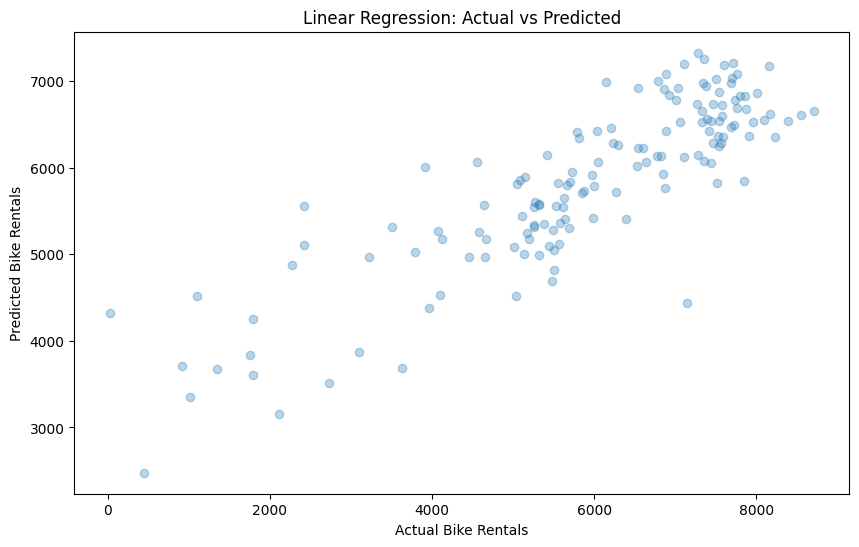

In [42]:
# Actual vs Predicted plot
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred_lr, alpha=0.3)

plt.xlabel("Actual Bike Rentals")
plt.ylabel("Predicted Bike Rentals")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

In [43]:
# Save the result
results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [mae_lr],
    "RMSE": [rmse_lr],
    "R2": [r2_lr]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,861.518613,1159.801793,0.617227


# 10. Random Forest Regression

* Random Forest Regressor is used to capture nonlinear relationships between the input features and bike rental demand. Its performance will be compared with the Linear Regression baseline using MAE, RMSE, and R².

In [44]:
# Import Random Forest
from sklearn.ensemble import RandomForestRegressor

In [45]:
# Create the model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [46]:
# Train the model
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [47]:
# Make predictions
y_pred_rf = rf_model.predict(X_test)

In [48]:
# Evaluate
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Results
---------------------
MAE : 898.1979591836736
RMSE: 1104.137116910203
R²  : 0.6530878948932031


In [49]:
# Add Random Forest to our results
results.loc[len(results)] = [
    "Random Forest",
    mae_rf,
    rmse_rf,
    r2_rf
]

results

,Model,MAE,RMSE,R2
0,Linear Regression,861.518613,1159.801793,0.617227
1,Random Forest,898.197959,1104.137117,0.653088


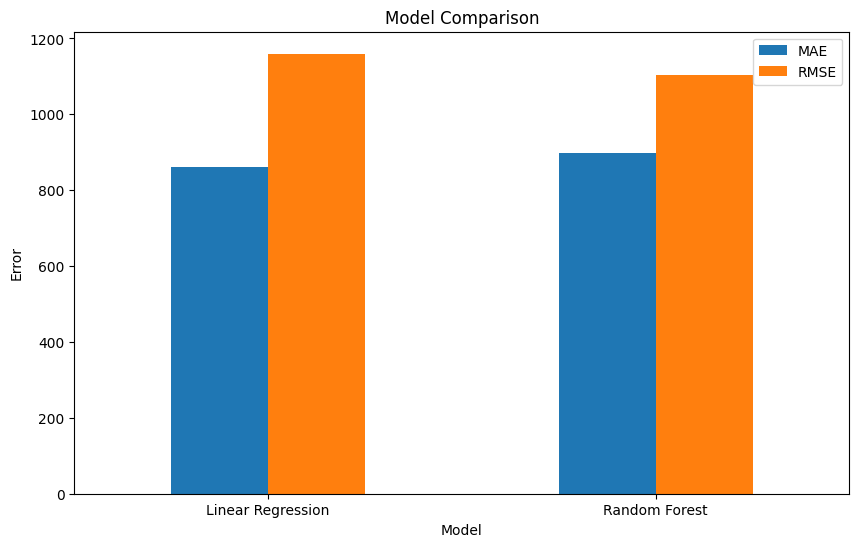

In [50]:
# Compare the models visually
results.set_index("Model")[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Comparison")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.show()

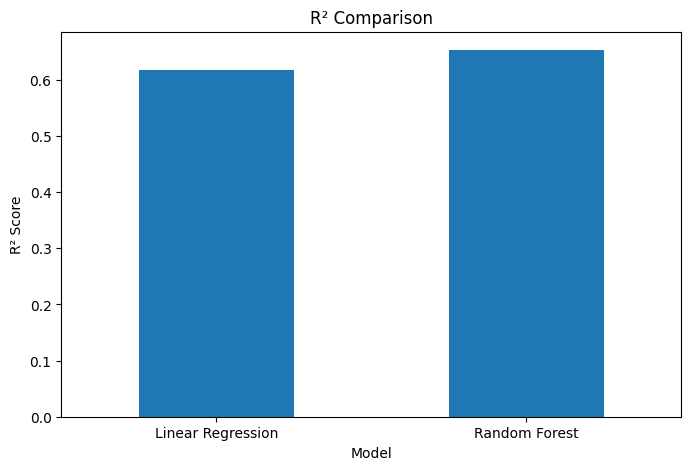

In [51]:
# And for R²:
results.set_index("Model")["R2"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("R² Comparison")
plt.ylabel("R² Score")
plt.xticks(rotation=0)
plt.show()

## Ridge Regression

In [52]:
# Import Ridge
from sklearn.linear_model import Ridge

# Create and train the model
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train, y_train)

# Make predictions
y_pred_ridge = ridge_model.predict(X_test)

# Evaluate
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Results")
print("-------------------------")
print("MAE :", mae_ridge)
print("RMSE:", rmse_ridge)
print("R²  :", r2_ridge)

Ridge Regression Results
-------------------------
MAE : 867.0963190568011
RMSE: 1162.357725674209
R²  : 0.6155383296742336


In [53]:
# Add Ridge to results
results.loc[len(results)] = ["Ridge Regression", mae_ridge, rmse_ridge, r2_ridge]
results

,Model,MAE,RMSE,R2
0,Linear Regression,861.518613,1159.801793,0.617227
1,Random Forest,898.197959,1104.137117,0.653088
2,Ridge Regression,867.096319,1162.357726,0.615538


## Decision Tree Regressor

In [54]:
# Import Decision Tree
from sklearn.tree import DecisionTreeRegressor

# Create and train the model
dt_model = DecisionTreeRegressor(max_depth=8, random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluate
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("----------------------")
print("MAE :", mae_dt)
print("RMSE:", rmse_dt)
print("R²  :", r2_dt)

Decision Tree Results
----------------------
MAE : 1035.6505563031074
RMSE: 1350.7113530163217
R²  : 0.48084321316586354


In [55]:
# Add Decision Tree to results
results.loc[len(results)] = ["Decision Tree", mae_dt, rmse_dt, r2_dt]
results

,Model,MAE,RMSE,R2
0,Linear Regression,861.518613,1159.801793,0.617227
1,Random Forest,898.197959,1104.137117,0.653088
2,Ridge Regression,867.096319,1162.357726,0.615538
3,Decision Tree,1035.650556,1350.711353,0.480843


## Gradient Boosting Regressor

In [56]:
# Import Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor

# Create and train the model
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)

# Make predictions
y_pred_gb = gb_model.predict(X_test)

# Evaluate
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Results")
print("--------------------------")
print("MAE :", mae_gb)
print("RMSE:", rmse_gb)
print("R²  :", r2_gb)

Gradient Boosting Results
--------------------------
MAE : 867.1993609778141
RMSE: 1037.296170198626
R²  : 0.6938184732624849


In [57]:
# Add Gradient Boosting to results
results.loc[len(results)] = ["Gradient Boosting", mae_gb, rmse_gb, r2_gb]
results

,Model,MAE,RMSE,R2
0,Linear Regression,861.518613,1159.801793,0.617227
1,Random Forest,898.197959,1104.137117,0.653088
2,Ridge Regression,867.096319,1162.357726,0.615538
3,Decision Tree,1035.650556,1350.711353,0.480843
4,Gradient Boosting,867.199361,1037.296170,0.693818


## Hyperparameter Tuning (Gradient Boosting)

* GridSearchCV is used to tune Gradient Boosting hyperparameters and find the best combination for improved performance.

In [58]:
# Hyperparameter tuning for Gradient Boosting
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5]
}

grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV R²:", grid.best_score_)

Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best CV R²: 0.3018971635399177


In [59]:
# Evaluate the tuned model on test data
best_gb_model = grid.best_estimator_
y_pred_best_gb = best_gb_model.predict(X_test)

mae_best_gb = mean_absolute_error(y_test, y_pred_best_gb)
rmse_best_gb = np.sqrt(mean_squared_error(y_test, y_pred_best_gb))
r2_best_gb = r2_score(y_test, y_pred_best_gb)

print("Tuned Gradient Boosting Results")
print("--------------------------------")
print("MAE :", mae_best_gb)
print("RMSE:", rmse_best_gb)
print("R²  :", r2_best_gb)

Tuned Gradient Boosting Results
--------------------------------
MAE : 833.0345670241612
RMSE: 1002.8560007468044
R²  : 0.7138125464180872


In [60]:
# Add Tuned Gradient Boosting to results
results.loc[len(results)] = ["Tuned Gradient Boosting", mae_best_gb, rmse_best_gb, r2_best_gb]
results

,Model,MAE,RMSE,R2
0,Linear Regression,861.518613,1159.801793,0.617227
1,Random Forest,898.197959,1104.137117,0.653088
2,Ridge Regression,867.096319,1162.357726,0.615538
3,Decision Tree,1035.650556,1350.711353,0.480843
4,Gradient Boosting,867.199361,1037.296170,0.693818
5,Tuned Gradient Boosting,833.034567,1002.856001,0.713813


## Save the Final Model

* The best performing model (Tuned Gradient Boosting) is saved using joblib for future use in production/deployment.

In [61]:
# Save the final model for deployment
import joblib

joblib.dump(best_gb_model, "gradient_boosting_bike_rental_model.pkl")
print("Model saved as gradient_boosting_bike_rental_model.pkl")

Model saved as gradient_boosting_bike_rental_model.pkl


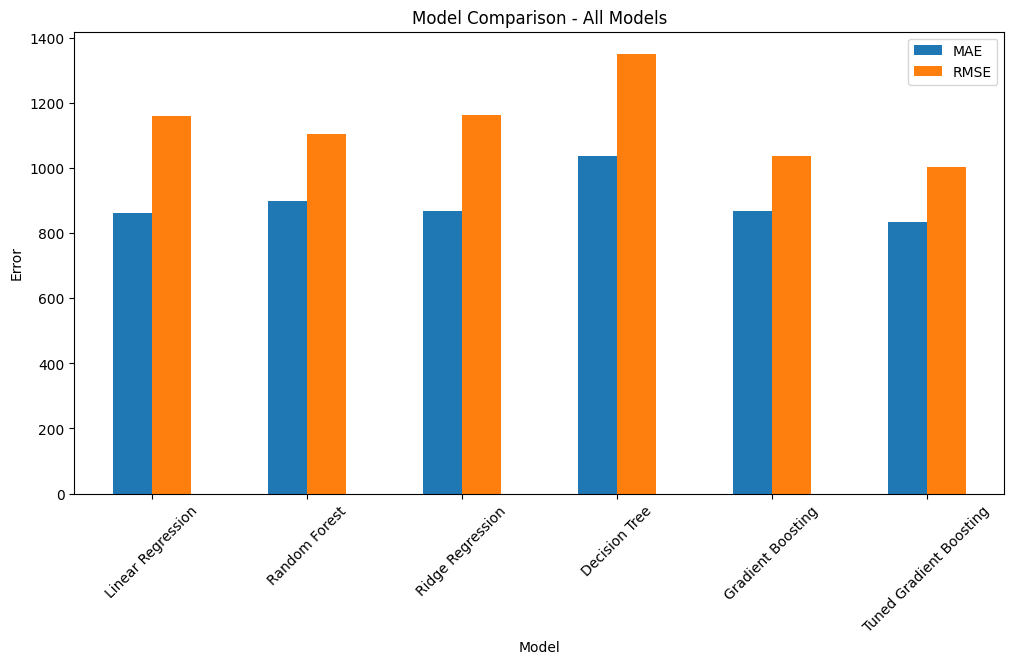

In [62]:
# Compare all models visually
results.set_index("Model")[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(12, 6)
)
plt.title("Model Comparison - All Models")
plt.ylabel("Error")
plt.xticks(rotation=45)
plt.show()

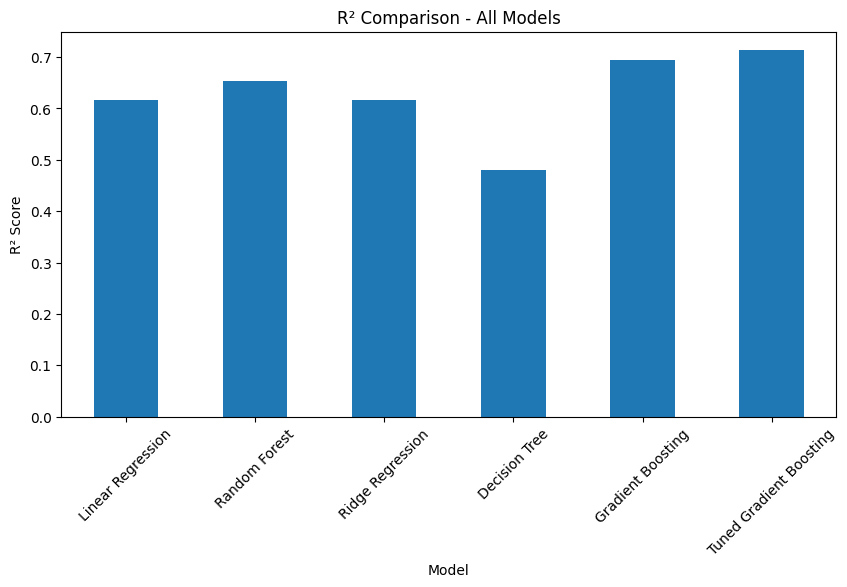

In [63]:
results.set_index("Model")["R2"].plot(
    kind="bar",
    figsize=(10, 5)
)
plt.title("R² Comparison - All Models")
plt.ylabel("R² Score")
plt.xticks(rotation=45)
plt.show()

# 11. Feature Importance

* Feature importance is used to identify which variables contribute most to the Random Forest model's predictions of bike rental demand.

In [64]:
# Calculate feature importance
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
7,temp,0.278568
8,atemp,0.276399
1,yr,0.246226
9,hum,0.058308
0,season,0.043164
10,windspeed,0.025868
2,mnth,0.023596
6,weathersit,0.019266
11,day,0.013003
4,weekday,0.010567


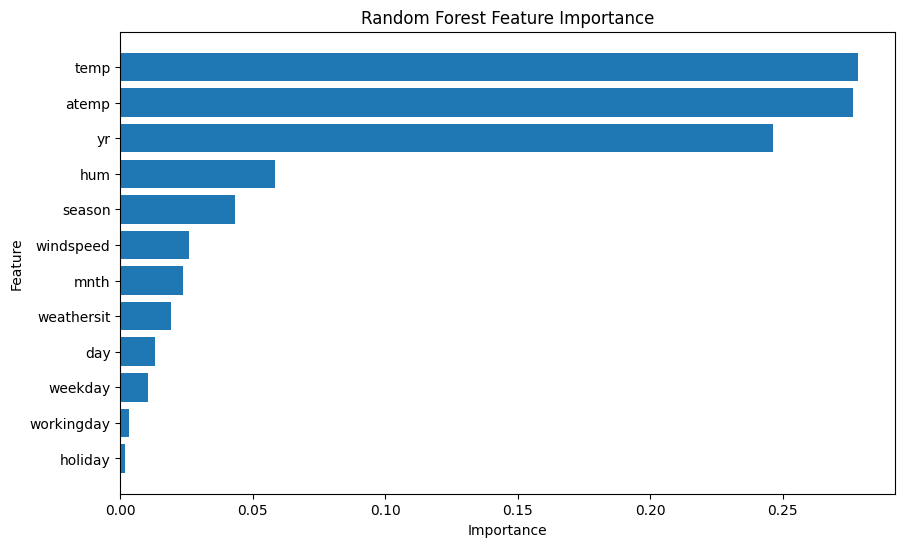

In [65]:
# Plot feature importance
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [66]:
# Top 10 features
feature_importance.head(10)

,Feature,Importance
7,temp,0.278568
8,atemp,0.276399
1,yr,0.246226
9,hum,0.058308
0,season,0.043164
10,windspeed,0.025868
2,mnth,0.023596
6,weathersit,0.019266
11,day,0.013003
4,weekday,0.010567


## Model Comparison Report

Six regression models were trained and evaluated on the bike rental dataset to predict daily rental count (`cnt`): Linear Regression, Random Forest, Ridge Regression, Decision Tree, Gradient Boosting, and Tuned Gradient Boosting.

| Model | MAE | RMSE | R² |
|---|---|---|---|
| Linear Regression | 861.52 | 1159.80 | 0.617 |
| Random Forest | 898.20 | 1104.14 | 0.653 |
| Ridge Regression | 867.10 | 1162.36 | 0.616 |
| Decision Tree | 1035.65 | 1350.71 | 0.481 |
| Gradient Boosting | 867.20 | 1037.30 | 0.694 |
| **Tuned Gradient Boosting** | 833.03 | **1002.86** | **0.714** |

**Observations:**
- Decision Tree performed the worst (R² = 0.481, highest RMSE), likely due to overfitting on training data and inability to generalize on unseen test data as a single tree.
- Linear Regression and Ridge Regression gave nearly identical results, indicating minimal multicollinearity issues after removing `casual` and `registered` columns.
- Random Forest improved over Linear Regression by capturing non-linear relationships between features and rental count.
- Gradient Boosting improved further over Random Forest by sequentially correcting errors from previous trees.
- **Tuned Gradient Boosting achieved the best performance** after GridSearchCV hyperparameter tuning, with the lowest RMSE (1002.86) and highest R² (0.714) among all models.

**Recommended Model for Production: Tuned Gradient Boosting Regressor**

It offers the best balance of accuracy (lowest RMSE) and explanatory power (highest R²), making it the most reliable choice for predicting daily bike rental counts based on environmental and seasonal factors. This is the model actually saved for deployment.

## Challenges Faced Report

**1. Data Leakage Risk (casual + registered columns)**
The `casual` and `registered` columns, when summed, exactly equal the target variable `cnt`. Including them as features would let the model "cheat" by directly reconstructing the target instead of learning genuine patterns from environmental and seasonal factors. 
*Technique used:* Both columns were dropped before model training to prevent data leakage.

**2. Multicollinearity between temp and atemp**
The correlation heatmap showed a strong positive correlation between `temp` (actual temperature) and `atemp` (feeling temperature), since both measure closely related physical quantities. 
*Technique used:* Both were retained since tree-based models (Random Forest, Gradient Boosting) are largely unaffected by multicollinearity; however, this was flagged as a consideration for linear models like Ridge Regression.

**3. Redundant Date Information**
After extracting `year` and `day` from `dteday`, it was found that the newly created `year` column duplicated information already present in the existing `yr` column (0/1 encoding). 
*Technique used:* The redundant `year` column was dropped to avoid duplicate features and reduce dimensionality.

**4. Chronological vs Random Train-Test Split**
Since bike rental data follows a time-based trend (yearly growth, seasonal cycles), a standard random `train_test_split` could mix future data into training and cause data leakage across time. 
*Technique used:* A chronological 80/20 split (`.iloc[]`) was used, preserving the natural time order so the model is evaluated on genuinely unseen future data.

**5. Model Underfitting/Overfitting Trade-off**
The Decision Tree model performed poorly (R² = 0.481) due to overfitting on training data with a single tree structure, while simpler models like Linear Regression underfit non-linear patterns. 
*Technique used:* Ensemble methods (Random Forest, Gradient Boosting) were used to balance bias and variance, ultimately yielding the best performance.

**6. GridSearchCV CV Score vs Test Score Gap**
`GridSearchCV`'s best cross-validation R² came out low (~0.30) even though the same tuned model scored R² = 0.714 on the actual held-out test set. This happened because the default `cv=3` uses unshuffled KFold on the already chronologically-ordered training data, so each fold covers a different, non-representative time chunk (different season/year mix).
*Technique used / note for future improvement:* Test-set performance is trustworthy since it preserves true time order, but for a more honest CV estimate during tuning, `TimeSeriesSplit` should be used instead of default KFold.

## Conclusion

This project analyzed bike rental data to predict daily rental counts (`cnt`) using environmental and seasonal features. After thorough data cleaning, EDA, and feature engineering, six regression models were trained and compared using a chronological train-test split.

**Final Model: Tuned Gradient Boosting Regressor**
- RMSE: 1002.86 (lowest among all models)
- R² Score: 0.714 (highest among all models)

Temperature (`temp`, `atemp`) and year (`yr`) emerged as the most influential features driving rental demand. The tuned Gradient Boosting model is saved as `gradient_boosting_bike_rental_model.pkl` and is recommended for production deployment to forecast daily bike rental demand.